# Telecom Company - Customer Churn Analysis

In [1]:
#importing the required libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.ticker as mtick  
import matplotlib.pyplot as plt

## Loading dataset and doing sanity checks

In [2]:
df = pd.read_csv("Customer_Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("The dataset has {0} rows and {1} columns".format(df.shape[0],df.shape[1]))

The dataset has 7043 rows and 21 columns


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

* TotalCharges column should be of type float64 instead of object(string)
* It makes more sense for SeniorCitizen column should be a categorical variable(Yes/No)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


* 75% customers have tenure less than 55 months with median around 29 months

* Average Monthly charges are 64.76$ whereas 25% customers pay more than USD 89.85 per month

* Since mean and median are close to each other for both tenure and MonthlyCharges, we can conclude their distribution across our dataset is not too skewed

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


* No null values can be seen right now but we'll check again after data cleaning

In [9]:
#  Checking distribution of target variable
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

(0.0, 5950.099999999999)

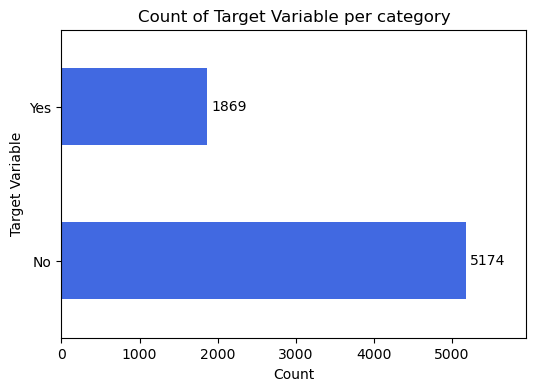

In [10]:
# Visualizing it
ax = df.Churn.value_counts().plot(kind = 'barh',color ='royalblue',figsize = (6,4))
ax.bar_label(ax.containers[0], padding=3)
plt.xlabel("Count")
plt.ylabel("Target Variable")
plt.title("Count of Target Variable per category")

# Adding some padding to the right so the label doesn't get cut off
plt.xlim(0, df.Churn.value_counts().max() * 1.15) 

In [11]:
100*df.Churn.value_counts()/len(df.Churn)

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

* Target Variable is highly imbalanced, ratio = 73:27
* We need to analyse later in EDA stage if this class imbalance can be attributed to certain features in the dataset

## Data Cleaning

### Create a copy of original dataset for manupulation & processing

In [12]:
new_df = df.copy()

### Transforming Datatype of Senior Citizen and Total charges column

In [13]:
new_df.SeniorCitizen = new_df.SeniorCitizen.apply(lambda x: 'Yes' if x ==1 else ('No' if x==0 else None))

In [14]:
new_df.SeniorCitizen.value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

In [15]:
new_df.TotalCharges = pd.to_numeric(new_df.TotalCharges,errors='coerce')

In [16]:
new_df.TotalCharges.dtype

dtype('float64')

In [17]:
new_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Datatype of all columns seems good now

### Checking for null values again

In [19]:
new_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

We have got some null values after data transformation, so lets check them out 

In [20]:
new_df.loc[new_df['TotalCharges'].isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Lets look at % of missing values using a seaborn pointplot

In [21]:
# Checking if this works before visualizing data
# reset_index is used to restore a continous index so it makes our % of missing values data easy to visualize
missing = pd.DataFrame(data=new_df.isnull().sum()*100/new_df.shape[0]).reset_index()
missing.rename(columns={0: 'percentage_missing_values'}, inplace=True)
missing.head()

,index,percentage_missing_values
0,customerID,0.0
1,gender,0.0
2,SeniorCitizen,0.0
3,Partner,0.0
4,Dependents,0.0


In [22]:
missing.loc[missing['index']=='TotalCharges']

,index,percentage_missing_values
19,TotalCharges,0.156183


Text(0.5, 0, 'Feature')

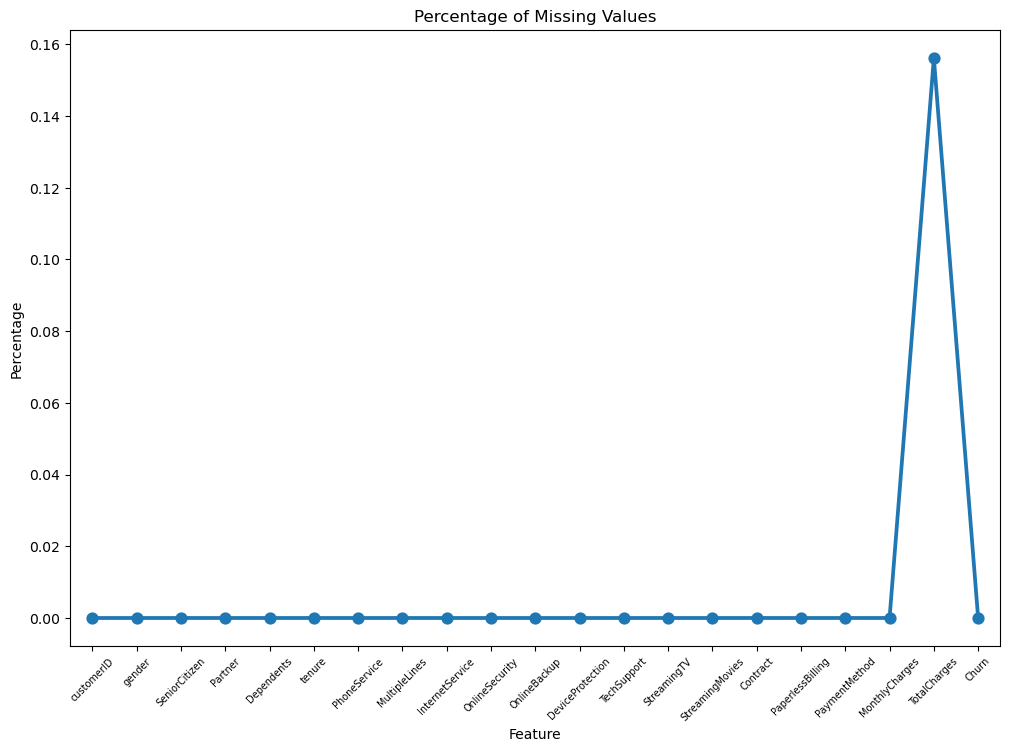

In [23]:
# Visualizing missing values now
plt.figure(figsize=(12,8))
ax = sns.pointplot(data=missing,x='index',y='percentage_missing_values')
plt.xticks(rotation = 45,fontsize=7)
plt.title("Percentage of Missing Values")
plt.ylabel("Percentage")
plt.xlabel("Feature")

* All the null value rows are for non-churned customers, tenure for each customer is 0 and there are no outliers as such if we look at Monthly charges column
* Since the no of null value rows < 1% and no significant data seems to present for these rows - we can go ahead and drop them instead of doing any missing value imputation

### Missing Value Treatment

In [24]:
new_df.dropna(how='any',inplace=True)

In [25]:
new_df.shape

(7032, 21)

The 11 rows with null value in TotalCharges column have been dropped now

### Dropping duplicate/meaningless columns

In [26]:
# Column CustomerID is meaningless for the predictive model we're going to build as it's just a unique ID
# axis =1 is the deafult argument which means we are selecting to drop column. axis = 0 is for dropping rows
new_df.drop(columns=['customerID'],axis=1,inplace=True)

## EDA (Exploratory Data Analysis) & Feature Engineering

### Univariate Analysis

In [27]:
new_df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

Lets convert the continous variable tenure into meaningful bins so we can get better insights

In [29]:
# Checking the range of tenure
new_df.tenure.min(), new_df.tenure.max()

(1, 72)

In [30]:
# It makes sense to divide customers into tenure bins of 12 months, i.e. 1-12 months, 12-24 months,24-36 months and so on
labels = ['{0} - {1}'.format(i,i+11) for i in range(1,72,12)]
print(labels)

['1 - 12', '13 - 24', '25 - 36', '37 - 48', '49 - 60', '61 - 72']


In [31]:
# Applying changes to tenure column in dataframe
new_df['tenure_group'] = pd.cut(new_df.tenure,bins=range(1,80,12),right=False,labels=labels)

In [32]:
new_df['tenure_group'].value_counts()

tenure_group
1 - 12     2175
61 - 72    1407
13 - 24    1024
25 - 36     832
49 - 60     832
37 - 48     762
Name: count, dtype: int64

In [33]:
# Dropping column tenure as well since its no longer needed for processing
new_df.drop(columns=['tenure'],axis=1,inplace=True)

In [34]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


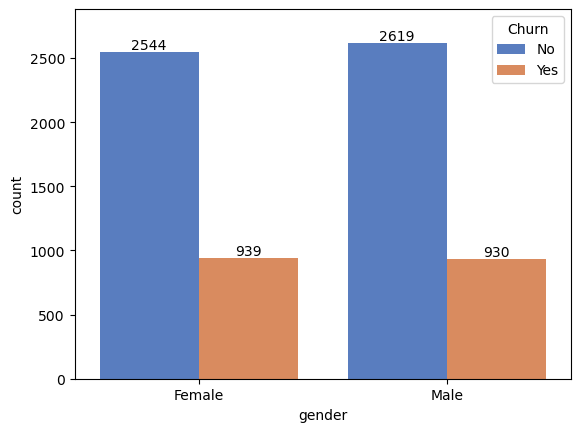

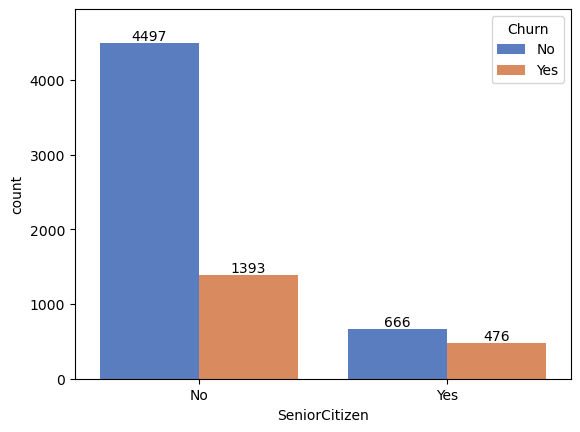

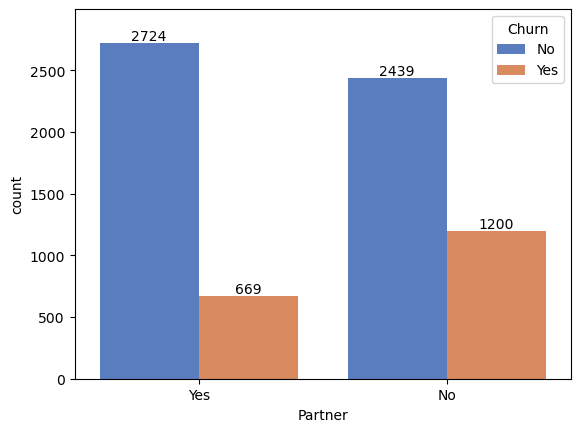

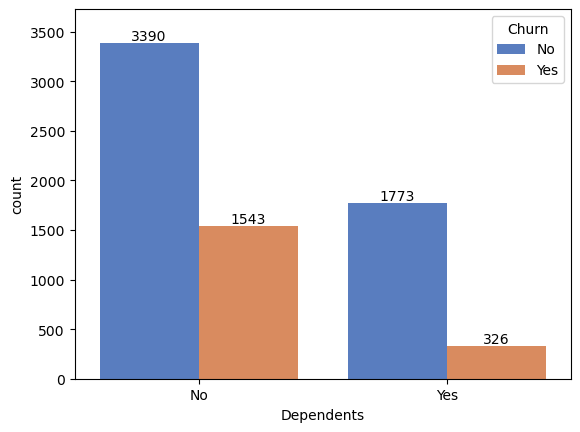

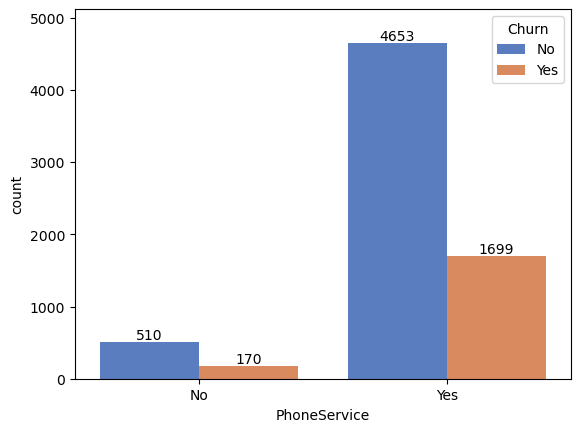

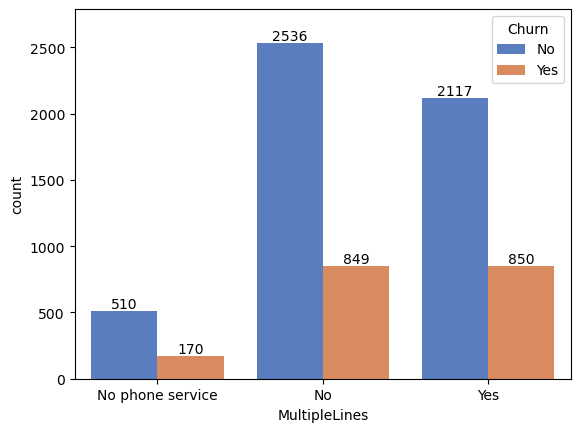

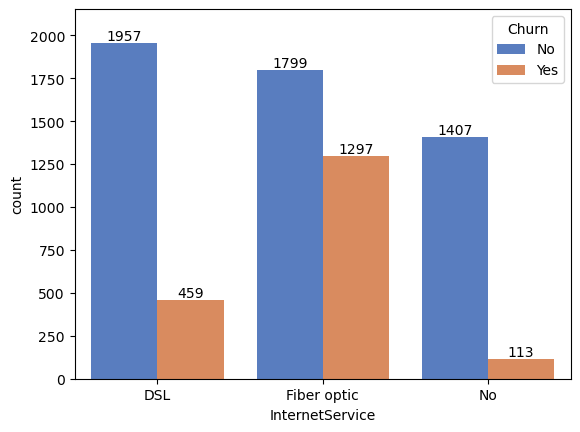

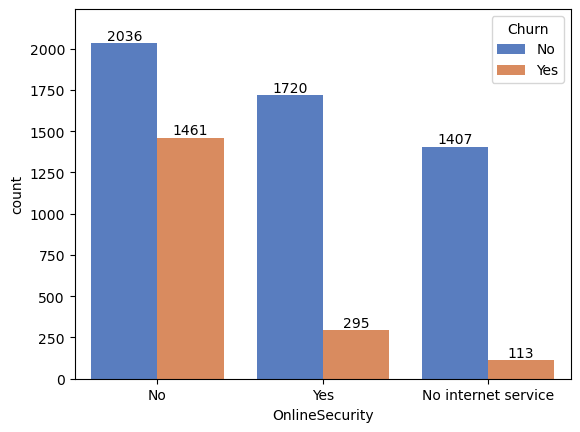

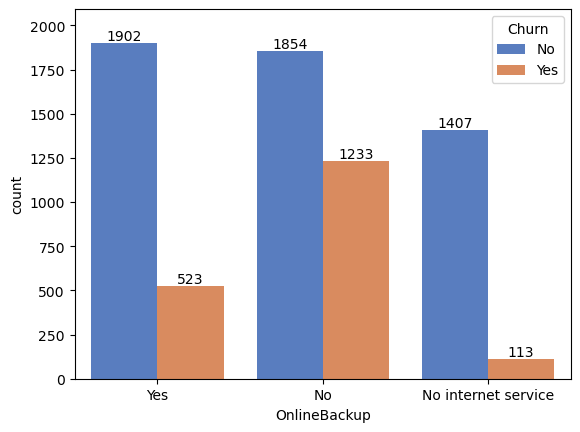

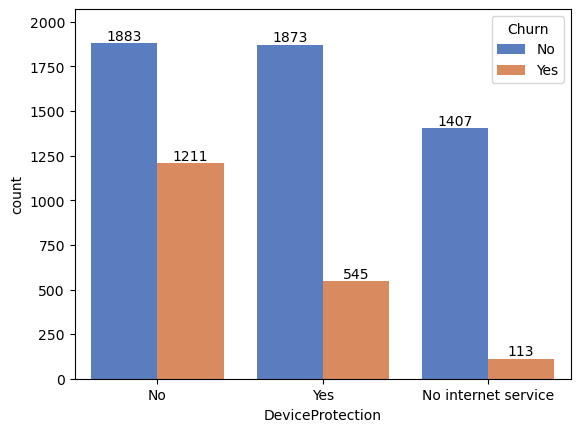

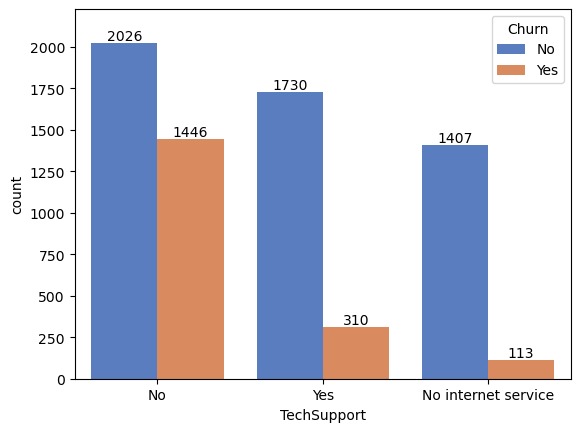

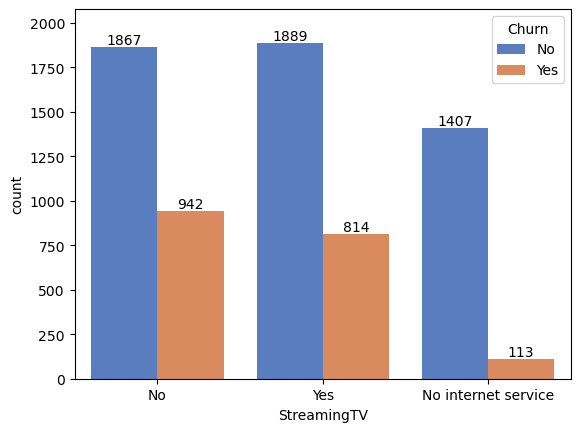

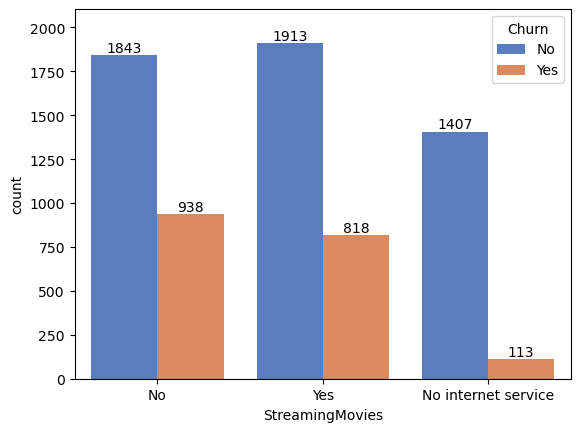

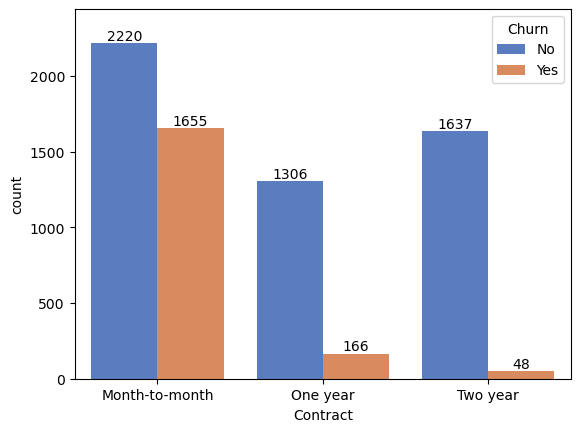

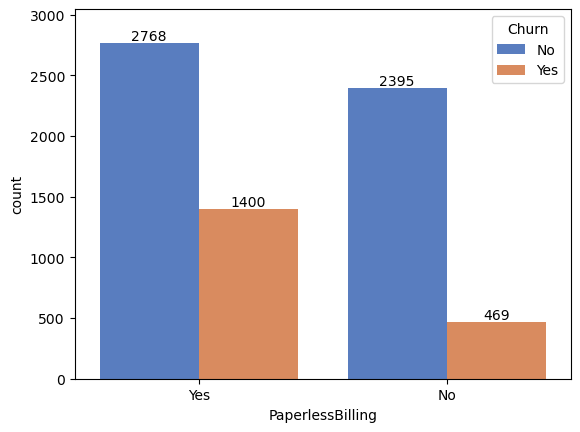

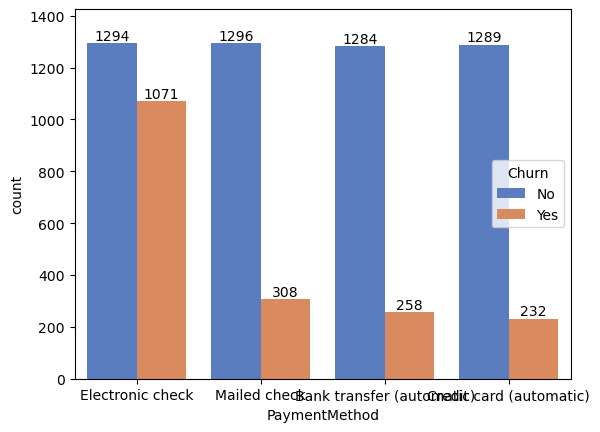

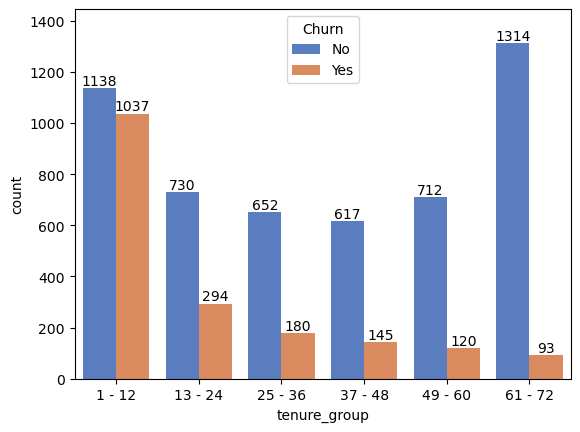

In [36]:
# Doing univariate analysis for all categorical columns first
# When we hue parameter, Seaborn creates separate groups of bars. Each group is stored as a container in the ax.containers attribute.
for i, feature in enumerate(new_df.drop(columns=["Churn","MonthlyCharges","TotalCharges"])):
    plt.figure(i)
    ax = sns.countplot(data=new_df,palette='muted',x=feature,hue='Churn')
    for container in ax.containers:
        ax.bar_label(container)
        
    ax.margins(y=0.1)

#### Observations

1. Senior Citizens seem more likely to churn
2. Users without partners seem more likely to churn.
3. Users without dependendts seem more likely to churn.
4. Users in tenure_group 1-12 and 13-24 months seem more likely to churn
5. Users who have opted for fiber optic as internet service seem to have higher rate of churn than other categories of internet service
6. Users who don't have online security seem to have a higher rate of churn than those who have it
7. Users who have online backup seem to have a higher rate of churn than thoe who don't
8. Users who don't have Device protection seem to have a higher rate of churn than those who have it
9. Users who didn't have tech support are more likely to churn
10. Users with month-to-month contract have the highest churn %
11. Users who prefer paperless billing seem more likely to churn
12. Users who paid via Electronic check seem more likely to churn than those using other payment methods 
13. Features Gender, PhoneSevice, MultipleLines, StreamingTV by themselves doesn't seem to useful features in differentatiating between churn and non-churn users

### Feature Engineering Part 1

Transforming target variable churn into a binary variable

In [37]:
new_df['Churn'] = np.where(new_df.Churn=='Yes',1,0)

In [38]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


Converting all categorical variables to dummy variables

In [39]:
latest_df = pd.get_dummies(new_df)
latest_df.head()

,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,29.85,29.85,0,True,False,True,False,False,True,True,...,False,False,True,False,True,False,False,False,False,False
1,56.95,1889.50,0,False,True,True,False,True,False,True,...,False,False,False,True,False,False,True,False,False,False
2,53.85,108.15,1,False,True,True,False,True,False,True,...,False,False,False,True,True,False,False,False,False,False
3,42.30,1840.75,0,False,True,True,False,True,False,True,...,True,False,False,False,False,False,False,True,False,False
4,70.70,151.65,1,True,False,True,False,True,False,True,...,False,False,True,False,True,False,False,False,False,False


### BiVariate Analysis Part 1

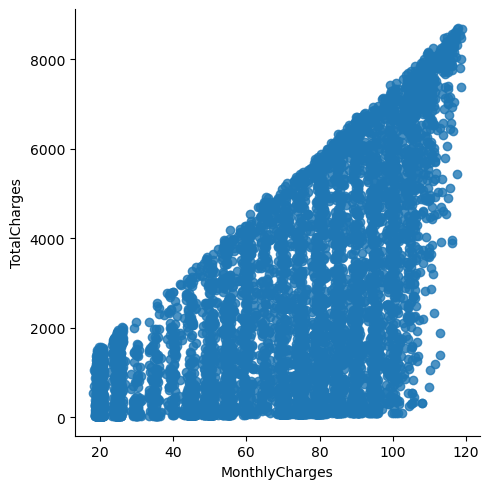

In [40]:
# Plotting relationship between Monthlycharges and Totalcharges
sns.lmplot(data = latest_df,x= 'MonthlyCharges',y='TotalCharges',fit_reg=False)

For most of data points, TotalCharges is positively correlated with MonthlyCharges as expected

In [41]:
# Exact value of peaeson correlation coefficient
float(latest_df['TotalCharges'].corr(latest_df['MonthlyCharges']))

0.6510648032262024

Text(0.5, 1.0, 'Monthly charges by churn')

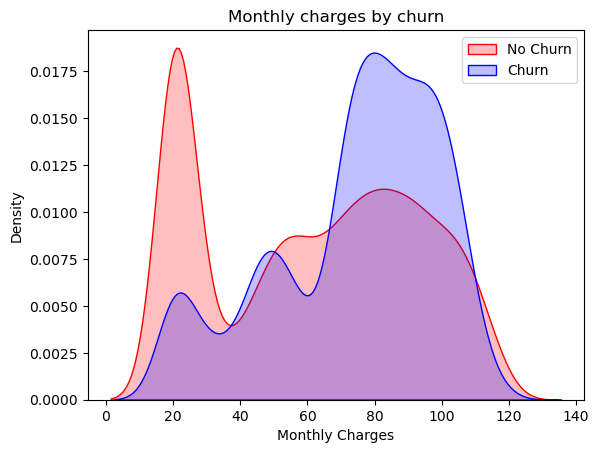

In [42]:
# Looking at Churn patterns across a range of monthly charges
mnth = sns.kdeplot(latest_df.MonthlyCharges[latest_df['Churn']==0],color='red',fill= True)
mnth = sns.kdeplot(latest_df.MonthlyCharges[latest_df['Churn']==1],ax=mnth,color='blue',fill= True)
mnth.legend(["No Churn","Churn"],loc='upper right')
mnth.set_ylabel('Density')
mnth.set_xlabel('Monthly Charges')
mnth.set_title('Monthly charges by churn')

**Insight**: Churn is high when monthly charges are high

Text(0.5, 1.0, 'Total charges by churn')

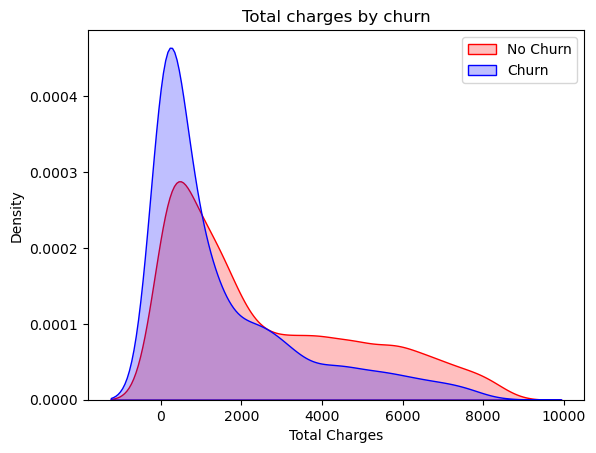

In [43]:
# Looking at Churn patterns across a range of Total charges
mnth = sns.kdeplot(latest_df.TotalCharges[latest_df['Churn']==0],color='red',fill= True)
mnth = sns.kdeplot(latest_df.TotalCharges[latest_df['Churn']==1],ax=mnth,color='blue',fill= True)
mnth.legend(["No Churn","Churn"],loc='upper right')
mnth.set_ylabel('Density')
mnth.set_xlabel('Total Charges')
mnth.set_title('Total charges by churn')

In [44]:
# Further exploration
latest_df['MonthlyCharges'].describe(), print('\n'), latest_df['TotalCharges'].describe()

(count    7032.000000
 mean       64.798208
 std        30.085974
 min        18.250000
 25%        35.587500
 50%        70.350000
 75%        89.862500
 max       118.750000
 Name: MonthlyCharges, dtype: float64,
 None,
 count    7032.000000
 mean     2283.300441
 std      2266.771362
 min        18.800000
 25%       401.450000
 50%      1397.475000
 75%      3794.737500
 max      8684.800000
 Name: TotalCharges, dtype: float64)

**Surprising insight**: Higher Churn is seen for customers paying lower Total Charges

However, if we combine the insights of 3 parameters - Tenure, Monthly Charges & Total Charges then the picture is more clear :- Higher Monthly Charge at lower tenure results into lower Total Charge. Hence, all these 3 factors viz **Higher Monthly Charge**,  **Lower tenure** and **Lower Total Charge** are linked to **High Churn**.

<Axes: >

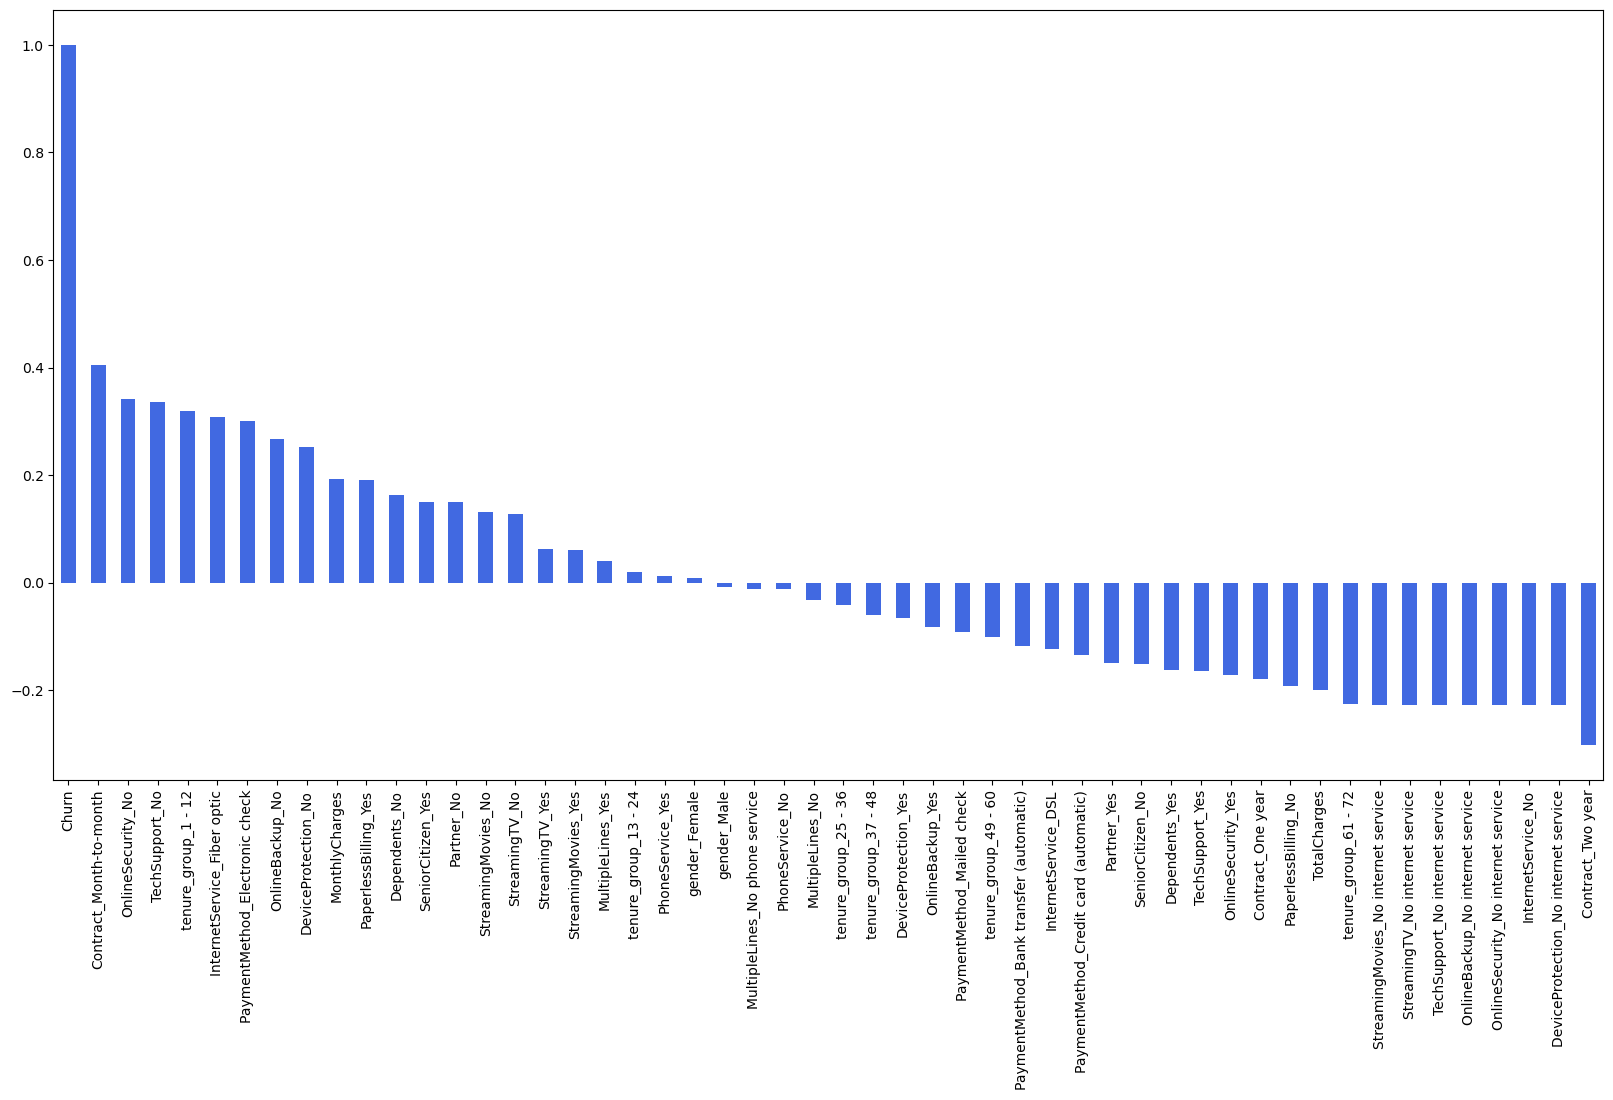

In [45]:
# Building a correlation of all predictors with Churn
plt.figure(figsize=(20,10))
latest_df.corr()['Churn'].sort_values(ascending=False).plot(kind='bar',color='royalblue')

In [46]:
corr_values = latest_df.corr()['Churn'].sort_values(ascending=False)
print(np.median(corr_values[corr_values!=1]))
corr_values[(corr_values >= 0.3) | (corr_values <= -0.3)]

-0.04099747819958552


Churn                             1.000000
Contract_Month-to-month           0.404565
OnlineSecurity_No                 0.342235
TechSupport_No                    0.336877
tenure_group_1 - 12               0.319628
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
Contract_Two year                -0.301552
Name: Churn, dtype: float64

**Insights:**

We can Use a correlation threshold of >=0.3 or <=-0.3. We can also use  top/bottom 5 correlation values. Either way, its clear that **HIGH** Churn seen in case of  **Month to month contracts**, **No online security**, **No Tech support**, **First year of subscription** and **Fibre Optics Internet**

**LOW** Churn is seens in case of **Long term contracts**, **Subscriptions without internet service**(considered just for high frequency on right side of above graph) and **The customers engaged for 5+ years**

Factors like **Gender**, **Availability of PhoneService** and **# of multiple lines** have almost **NO** impact on Churn

<Axes: >

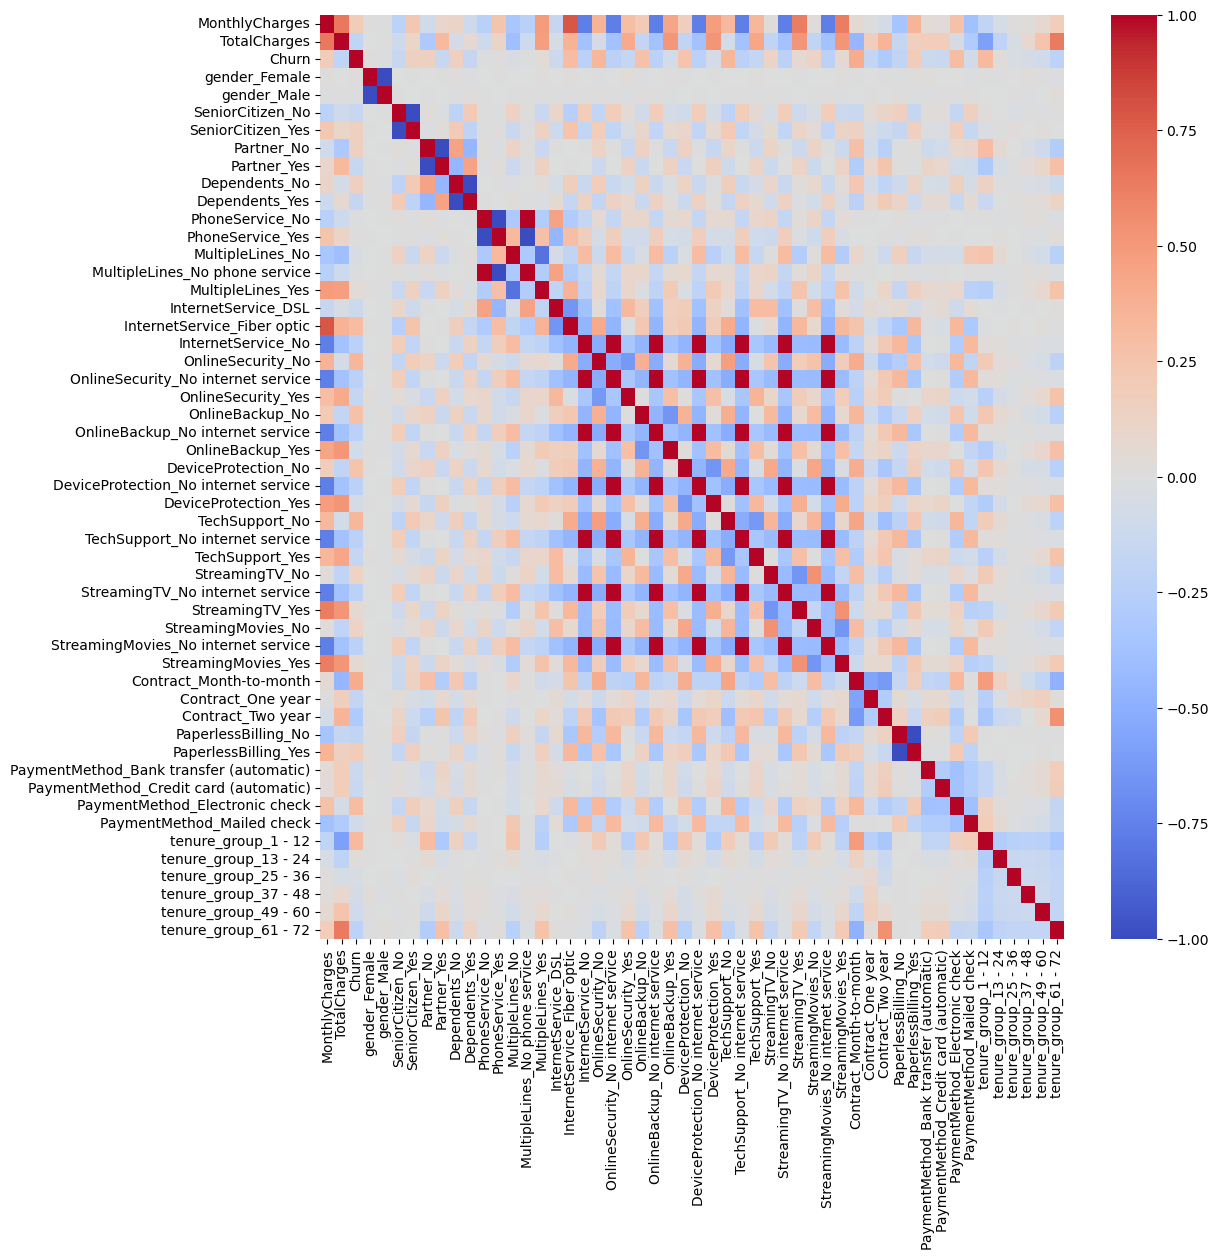

In [47]:
 # Building heatmap below to confirm insights
plt.figure(figsize=(12,12))
sns.heatmap(latest_df.corr(),cmap='coolwarm')

### Bivariate Analysis Part 2

In [59]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


In [48]:
### Bivariate Analysis
new_df1_target0=new_df.loc[new_df["Churn"]==0] #Active Customers
new_df1_target1=new_df.loc[new_df["Churn"]==1] #Churned Customers

In [49]:
len(new_df1_target0)

5163

In [50]:
len(new_df1_target1)

1869

In [60]:
def uniplot(df,col,title,hue =None):
    
    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30
    
    
    temp = pd.Series(data = hue)
    fig, ax = plt.subplots()
    width = len(df[col].unique()) + 7 + 4*len(temp.unique())
    fig.set_size_inches(width , 8)
    plt.xticks(rotation=45)
    # plt.yscale('log')
    plt.title(title)
    ax = sns.countplot(data = df, x= col, order=df[col].value_counts().index,hue = hue,palette='bright') 
        
    plt.show()

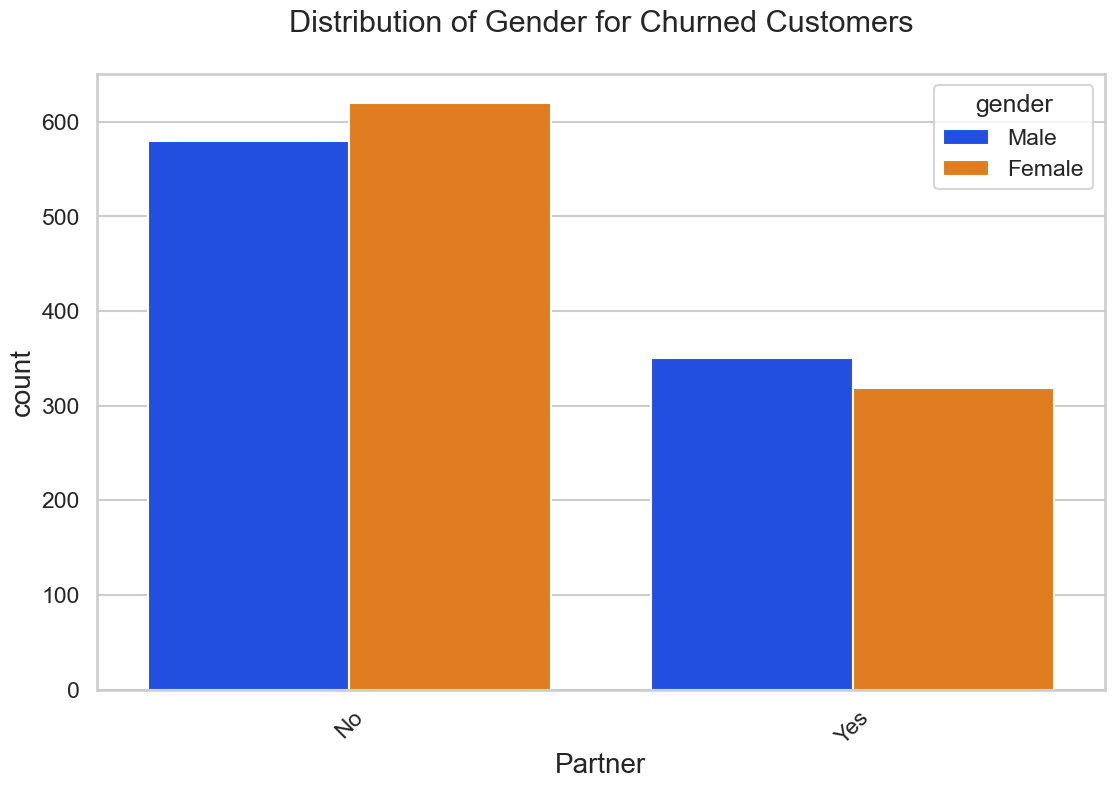

In [61]:
uniplot(new_df1_target1,col='Partner',title='Distribution of Gender for Churned Customers',hue='gender')

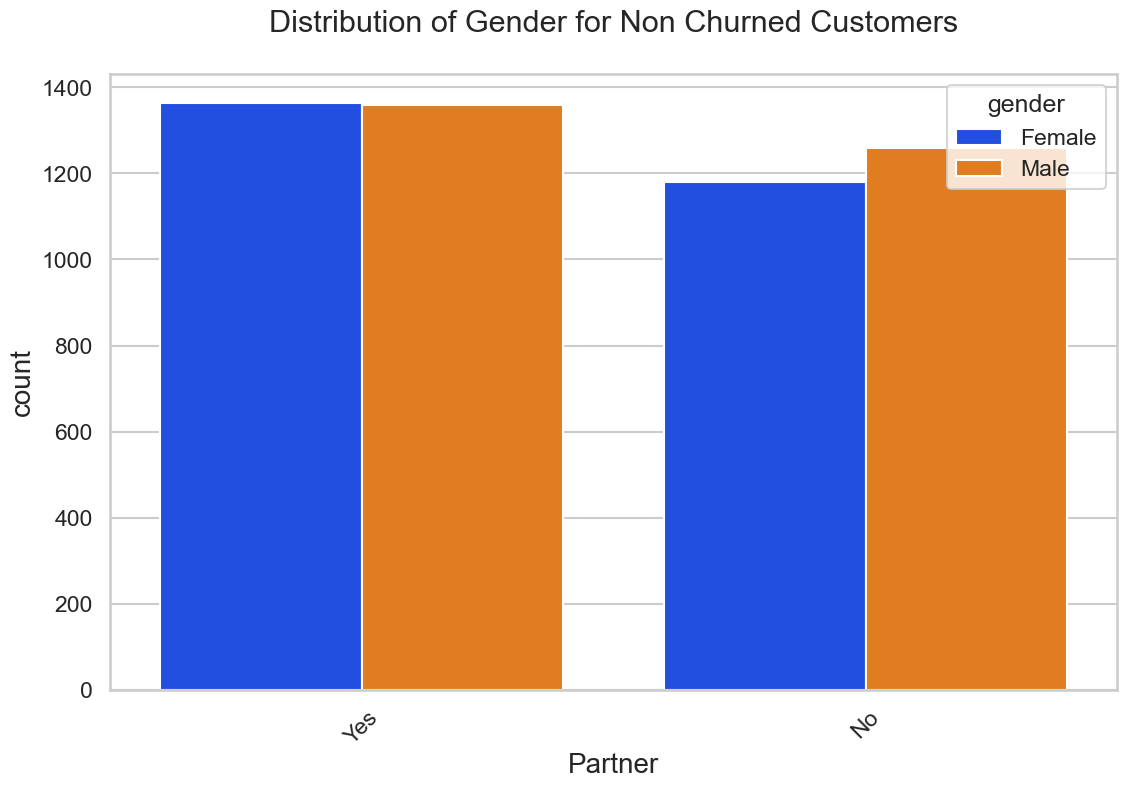

In [62]:
uniplot(new_df1_target0,col='Partner',title='Distribution of Gender for Non Churned Customers',hue='gender')

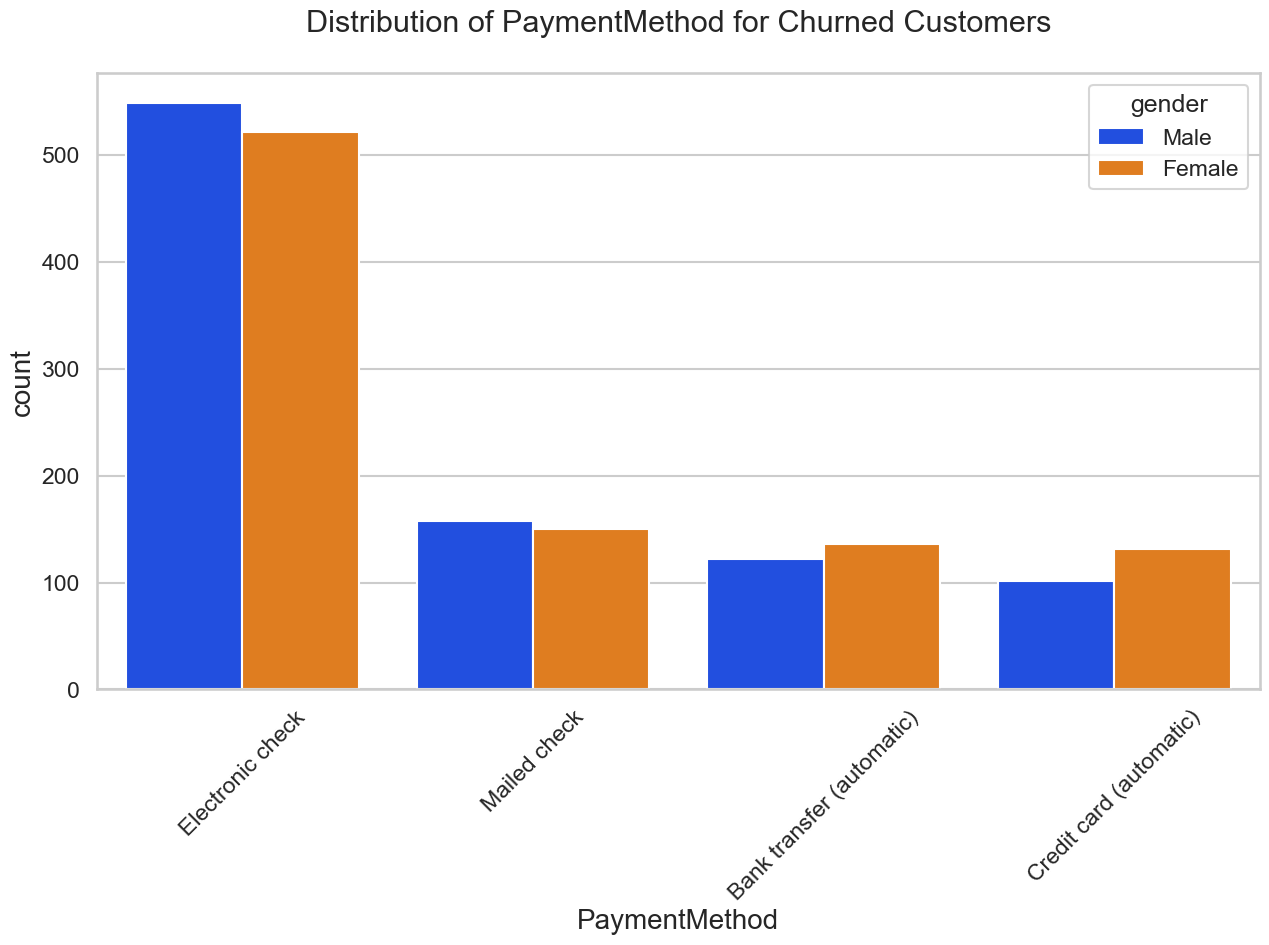

In [63]:
uniplot(new_df1_target1,col='PaymentMethod',title='Distribution of PaymentMethod for Churned Customers',hue='gender')

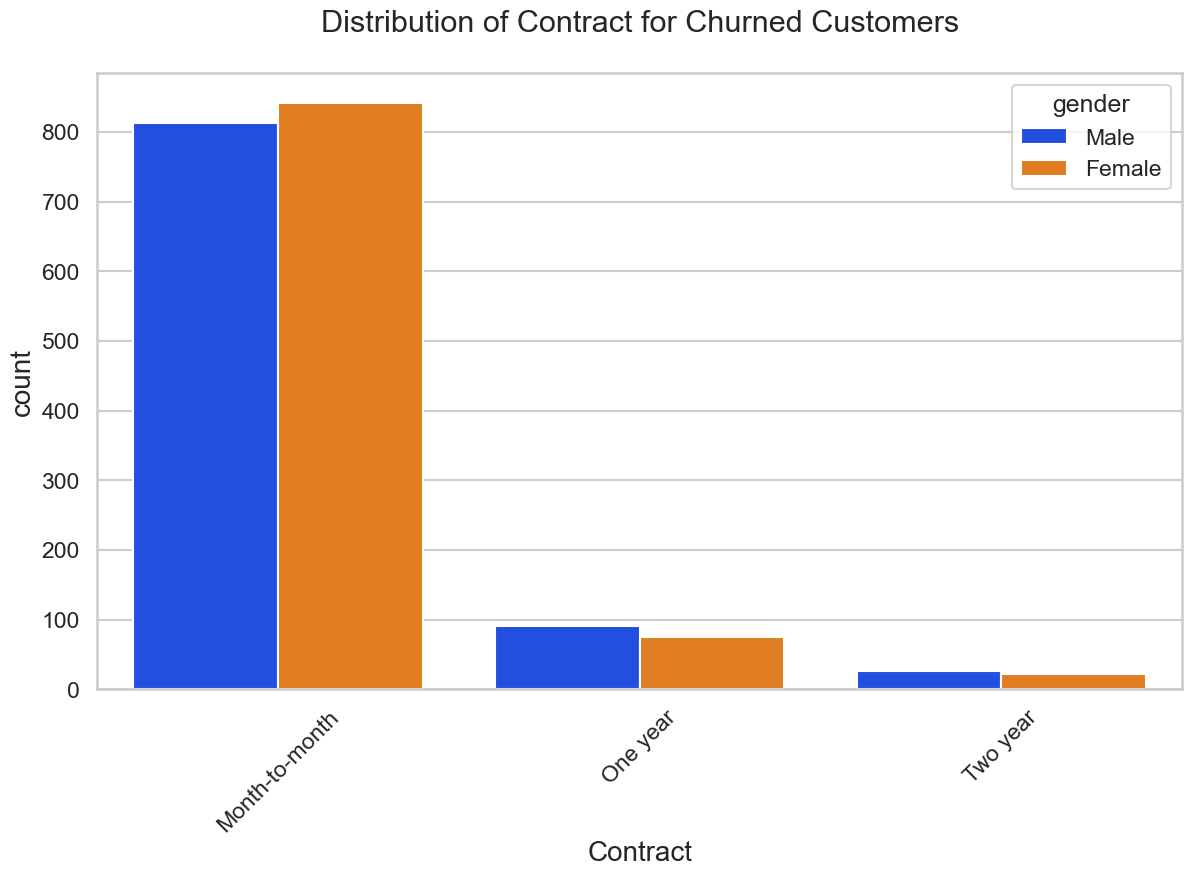

In [64]:
uniplot(new_df1_target1,col='Contract',title='Distribution of Contract for Churned Customers',hue='gender')

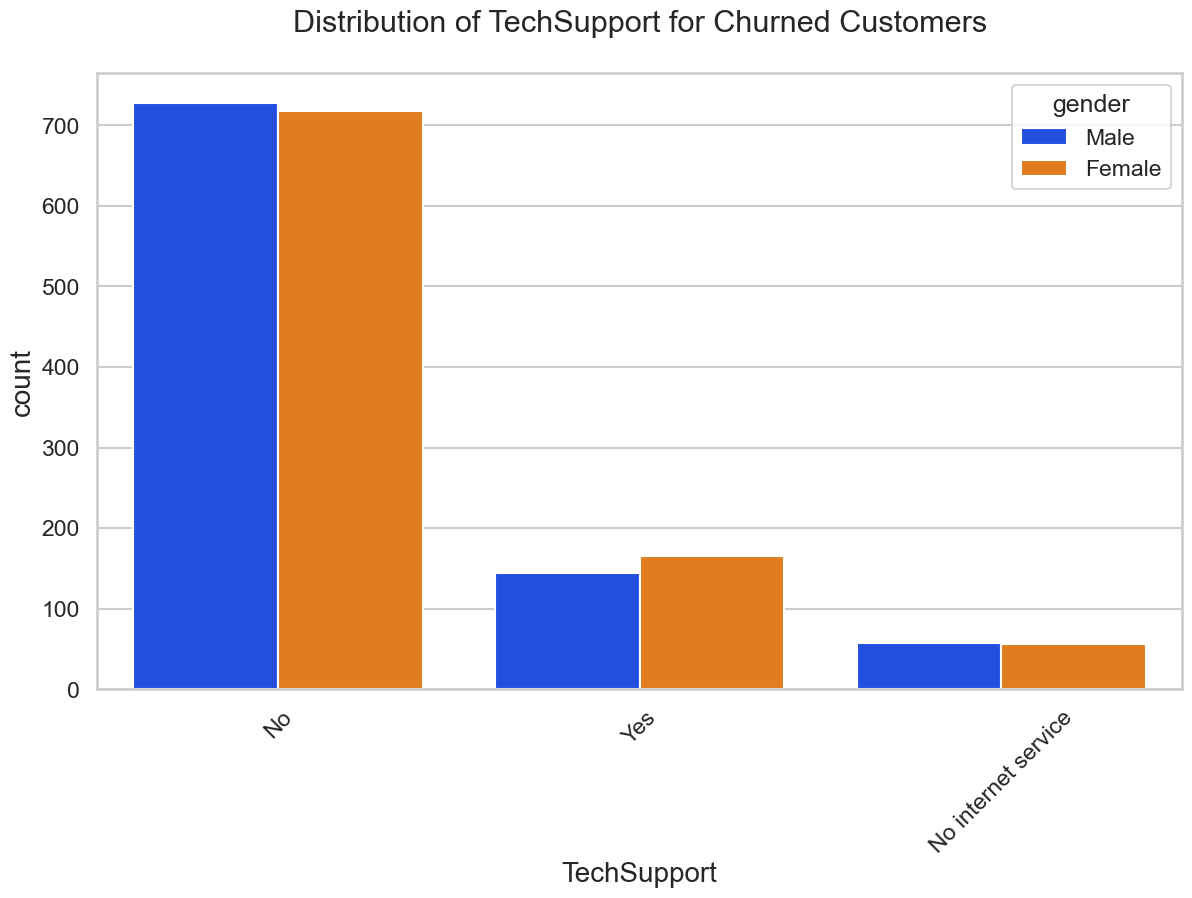

In [65]:
uniplot(new_df1_target1,col='TechSupport',title='Distribution of TechSupport for Churned Customers',hue='gender')

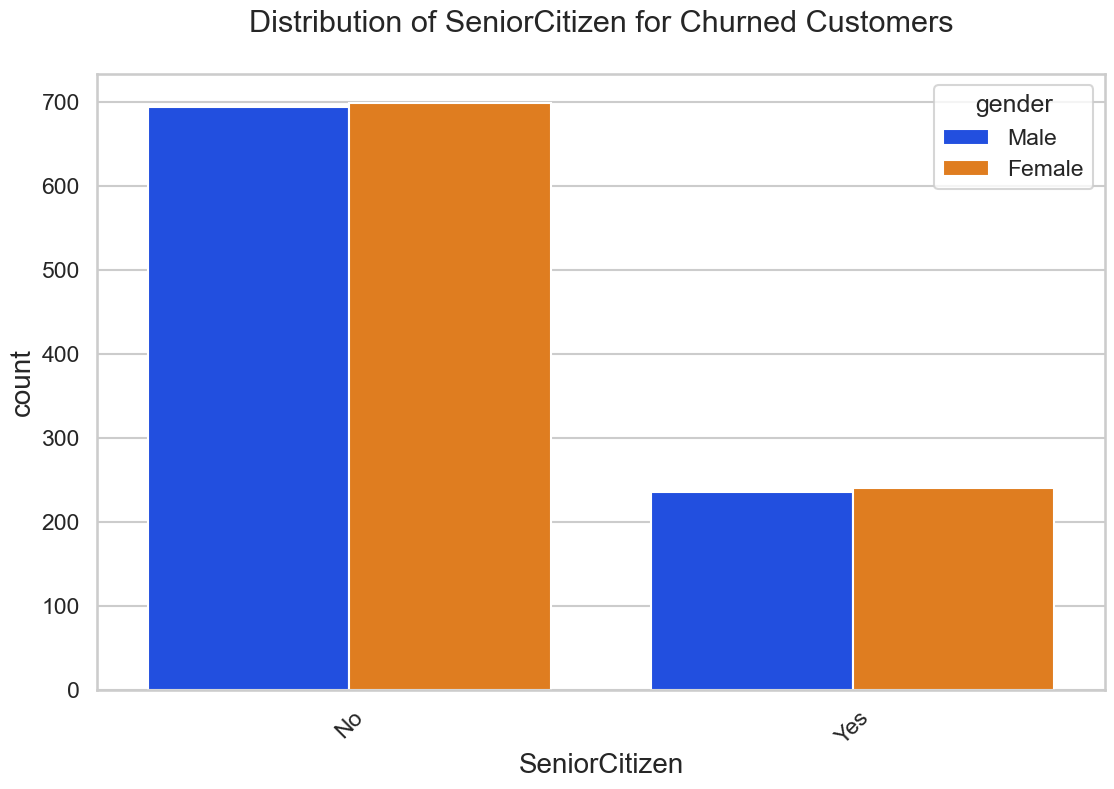

In [66]:
uniplot(new_df1_target1,col='SeniorCitizen',title='Distribution of SeniorCitizen for Churned Customers',hue='gender')

# CONCLUSION
These are some of the quick insights from this exercise:

1. Electronic check medium are the highest churners
2. Contract Type - Monthly customers are more likely to churn because of no contract terms, as they are free to go customers.
3. No Online security, No Tech Support category are high churners
4. Non senior Citizens are high churners

Note: There could be many more such insights, so take this as an assignment and try to get more insights :)
1. Senior Citizens are more likely to churn, they have a churn rate of ~42%
2. People with no Partners are more likely to churn, they have a churn rate of ~35%
3. Monthly customers are more likely to churn, they have a churn rate of ~41%, people with 2 year contract are very less likely to churn
4. Almost 44% of the customers paying via Electronic check are churners
5. People with less tenure i.e 1-12 are very high churners
6. Higher Monthly Charge, Lower tenure and Lower Total Charge are linked to High Churn
7. Females who don't have partners are more likely to churn compared to their male counterparts
8. Females using credit card are very high churners as compared to their counterparts